# PokeAPI Analytics - Parte 1

Pipeline batch em camadas medallion (bronze, silver, gold) sobre a PokeAPI. Este
notebook é a camada de orquestração e narrativa: importa as funções já
implementadas e testadas em `src/` (`ingest`, `transform`, `quality`, `analysis`).
A lógica em si vive nos módulos, com sua própria suíte de testes (ver
`docs/IMPLEMENTATION.md`).

**Objetivo:** coletar o detalhe de todos os pokémons da PokeAPI, modelar 4 tabelas
silver com schema explícito, validar a qualidade dos dados e responder 3 perguntas
sobre o dataset.

**Ambiente:** PySpark "vanilla", sem `display`/`dbutils`/APIs exclusivas de
Databricks (ADR-0015). Roda em Docker local, Google Colab ou Databricks sem
alterações.

**Modelo de dados** (detalhe e diagrama ERD em
[`docs/ARCHITECTURE.md`](../docs/ARCHITECTURE.md)):

- `pokemon(pokemon_id, name, height, weight, base_experience)`
- `pokemon_type(pokemon_id, type_name)`
- `pokemon_stats(pokemon_id, stat_name, base_stat)`
- `pokemon_ability(pokemon_id, ability_name, is_hidden)`

In [1]:
import base64
import sys
import time
from datetime import datetime
from pathlib import Path

from IPython.display import Image, display

# Garante que `src` é importável tanto rodando a partir da raiz do projeto (Docker/CI)
# quanto de um ambiente Jupyter/Colab que clonou o repositório.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from src import ingest, transform, quality, analysis, report

In [2]:
spark = (
    SparkSession.builder.appName("part1-pokeapi-analytics-notebook")
    .master("local[*]")
    .getOrCreate()
)
spark

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/14 01:42:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Ingestão (bronze)

Coleta assíncrona com concorrência limitada e cache em disco por id (`ADR-0006`).
O cache bronze (`data/bronze/{id}.json`) torna reruns rápidos: se os arquivos já
existem, `fetch_all` não bate na API de novo.

Por padrão rodamos com o dataset completo (todos os pokémons da PokeAPI, para
as respostas reais). Para uma iteração rápida em desenvolvimento, basta trocar
`MAX_ITEMS` para um inteiro pequeno (ex.: `50`), o que vira um smoke test.

In [3]:
MAX_ITEMS = None # None = dataset completo; um int (ex.: 50) faz um smoke test rápido

t0 = time.time()
index = ingest.fetch_index(max_items=MAX_ITEMS)
urls = [entry["url"] for entry in index]
details = ingest.fetch_all(urls, concurrency=10, cache_dir="data/bronze")
ingest_seconds = time.time() - t0
print(f"Coletados {len(details)} pokémons em {ingest_seconds:.1f}s (cache bronze acelera reruns)")

Coletados 1351 pokémons em 26.8s (cache bronze acelera reruns)


## 2. Transformação (silver)

As 4 tabelas com `StructType` explícito (sem `inferSchema`, `ADR-0007`) e gravadas
em Parquet.

In [4]:
pokemon_df = transform.build_pokemon(details)
pokemon_type_df = transform.build_pokemon_type(details)
pokemon_stats_df = transform.build_pokemon_stats(details)
pokemon_ability_df = transform.build_pokemon_ability(details)

transform.write_silver(pokemon_df, "pokemon")
transform.write_silver(pokemon_type_df, "pokemon_type")
transform.write_silver(pokemon_stats_df, "pokemon_stats")
transform.write_silver(pokemon_ability_df, "pokemon_ability")

n_pokemon = pokemon_df.count()
n_pokemon_type = pokemon_type_df.count()
n_pokemon_stats = pokemon_stats_df.count()
n_pokemon_ability = pokemon_ability_df.count()

print(f"pokemon:         {n_pokemon:>5} linhas")
print(f"pokemon_type:    {n_pokemon_type:>5} linhas")
print(f"pokemon_stats:   {n_pokemon_stats:>5} linhas")
print(f"pokemon_ability: {n_pokemon_ability:>5} linhas")

26/09/14 01:43:17 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


26/09/14 01:43:27 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/14 01:43:27 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/14 01:43:27 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/14 01:43:27 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/14 01:43:27 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/14 01:43:27 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/14 01:43:27 WARN MemoryManager: Total allocation exceeds 95.

26/09/14 01:43:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 50.67% for 15 writers
26/09/14 01:43:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 54.29% for 14 writers
26/09/14 01:43:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/14 01:43:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/14 01:43:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/14 01:43:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/14 01:43:28 WARN MemoryManager: Total allocation exceeds 9

26/09/14 01:43:38 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/14 01:43:38 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/14 01:43:38 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/14 01:43:38 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/14 01:43:38 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/14 01:43:38 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/14 01:43:38 WARN MemoryManager: Total allocation exceeds 95.

26/09/14 01:43:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/14 01:43:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


pokemon:          1351 linhas
pokemon_type:     2116 linhas
pokemon_stats:    8106 linhas
pokemon_ability:  2941 linhas


## 3. Qualidade (portão silver -> gold)

`run_quality_report` imprime o relatório e levanta `DataQualityError` (fail loud)
se uma invariante crítica for violada: PK nula ou duplicada em `pokemon`, ou
órfãos em `pokemon_type`/`pokemon_stats`/`pokemon_ability`. Se esta célula
levantar, é para o notebook parar aqui: a camada gold nunca deve ser gerada a
partir de um silver inconsistente.

In [5]:
quality.run_quality_report(
    {
        "pokemon": pokemon_df,
        "pokemon_type": pokemon_type_df,
        "pokemon_stats": pokemon_stats_df,
        "pokemon_ability": pokemon_ability_df,
    }
)

RELATÓRIO DE QUALIDADE - silver
[PASS] [CRÍTICO] not_null(pokemon_id): pokemon_id=0 nulos
[PASS] [CRÍTICO] unique(pokemon_id): 0 chave(s) duplicada(s)
[PASS] unique(pokemon_id, type_name): 0 chave(s) duplicada(s)
[PASS] [CRÍTICO] referential(pokemon_id): 0 órfão(s)
[PASS] [CRÍTICO] referential(pokemon_id): 0 órfão(s)
[PASS] [CRÍTICO] referential(pokemon_id): 0 órfão(s)


## 4. Análises (gold)

### Pergunta 1: multi-tipo e força acima da média

> Quantos pokémons têm mais de um tipo **e** força (soma de todos os `base_stat`)
> acima da média geral?

**Pegadinha:** "média geral da força" é a média das forças por pokémon
(`avg(forca)`, uma linha por pokémon), não a média linha a linha de `base_stat`
(que teria uma linha por combinação pokémon-stat e pesaria errado quem tem mais
stats registrados). `q1_multitype_above_avg` calcula a média sobre o DataFrame já
agregado por pokémon (ver `docs/IMPLEMENTATION.md`, Seção 4).

In [6]:
resultado_q1, detalhe_q1 = analysis.q1_multitype_above_avg(
    pokemon_df, pokemon_type_df, pokemon_stats_df
)

print(f"Resposta Q1: {resultado_q1} pokémons são multi-tipo E têm força acima da média.\n")
detalhe_q1.orderBy(F.col("forca").desc()).show(30, truncate=False)

Resposta Q1: 510 pokémons são multi-tipo E têm força acima da média.



+----------+----------------------+-----+-------+
|pokemon_id|name                  |forca|n_types|
+----------+----------------------+-----+-------+
|10190     |eternatus-eternamax   |1125 |2      |
|10043     |mewtwo-mega-x         |780  |2      |
|10079     |rayquaza-mega         |780  |2      |
|10301     |zygarde-mega          |778  |2      |
|10078     |groudon-primal        |770  |2      |
|10157     |necrozma-ultra        |754  |2      |
|10120     |zygarde-complete      |708  |2      |
|10058     |garchomp-mega         |700  |2      |
|10188     |zacian-crowned        |700  |2      |
|10062     |latias-mega           |700  |2      |
|10317     |magearna-mega         |700  |2      |
|10311     |heatran-mega          |700  |2      |
|10318     |magearna-original-mega|700  |2      |
|10281     |dragonite-mega        |700  |2      |
|10023     |kyurem-white          |700  |2      |
|10063     |latios-mega           |700  |2      |
|10325     |baxcalibur-mega       |700  |2      |


### Pergunta 2: abilities exclusivas de multi-tipo

> Quais abilities nunca aparecem em nenhum pokémon de tipo único?

**Lógica:** todas as abilities distintas menos as que aparecem em algum
pokémon mono-tipo (`distinct().subtract(...)`). Não é "aparece em algum
multi-tipo", porque isso deixaria passar abilities que também aparecem em
mono-tipo. Como toda ability vem de algum pokémon, o que sobra do `subtract`
só pode vir de pokémons multi-tipo.

In [7]:
q2_df = analysis.q2_abilities_exclusive_multitype(pokemon_type_df, pokemon_ability_df)
q2_abilities = sorted(row.ability_name for row in q2_df.collect())

print(f"Resposta Q2: {len(q2_abilities)} abilities exclusivas de multi-tipo.\n")
for name in q2_abilities:
    print(f"  - {name}")

Resposta Q2: 94 abilities exclusivas de multi-tipo.

  - aerilate
  - air-lock
  - armor-tail
  - as-one-glastrier
  - as-one-spectrier
  - aura-break
  - aura-guard
  - battery
  - battle-bond
  - beads-of-ruin
  - berserk
  - commander
  - corrosion
  - costar
  - curious-medicine
  - dancer
  - dark-aura
  - dazzling
  - defeatist
  - delta-stream
  - desolate-land
  - disguise
  - dragonize
  - dry-skin
  - emergency-exit
  - fire-mane
  - flare-boost
  - full-metal-body
  - gale-wings
  - galvanize
  - good-as-gold
  - gulp-missile
  - hadron-engine
  - harvest
  - hospitality
  - hunger-switch
  - ice-scales
  - iron-barbs
  - long-reach
  - mega-sol
  - merciless
  - mimicry
  - minds-eye
  - mirror-armor
  - misty-surge
  - multiscale
  - mycelium-might
  - neuroforce
  - orichalcum-pulse
  - piercing-drill
  - poison-puppeteer
  - power-construct
  - power-of-alchemy
  - protosynthesis
  - psychic-surge
  - punk-rock
  - pure-power
  - quark-drive
  - quick-draw
  - ripen
  - 

### Pergunta 3: top 5 versatilidade

> `versatility_score = (nº tipos x 2) + (nº abilities) + (soma dos stats / 100)`

`nº abilities` conta todas as habilidades distintas, incluindo as com
`is_hidden=true`. Empates são resolvidos por `pokemon_id` ascendente. Sem essa
chave de desempate, a ordem entre pokémons empatados na fronteira do top 5 não
seria determinística.

In [8]:
top5_df = analysis.q3_top5_versatility(
    pokemon_df, pokemon_type_df, pokemon_stats_df, pokemon_ability_df
)
top5_rows = top5_df.orderBy(
    F.col("versatility_score").desc(), F.col("pokemon_id").asc()
).collect()
top5_list = [
    {
        "pokemon_id": row.pokemon_id,
        "name": row.name,
        "versatility_score": row.versatility_score,
    }
    for row in top5_rows
]

print("Resposta Q3, top 5 versatilidade:\n")
for rank, row in enumerate(top5_list, start=1):
    print(f"  {rank}. {row['name']} (id={row['pokemon_id']}): score={row['versatility_score']:.2f}")

26/09/14 01:44:08 WARN CacheManager: Asked to cache already cached data.


Resposta Q3, top 5 versatilidade:

  1. eternatus-eternamax (id=10190): score=16.25
  2. kommo-o (id=784): score=13.00
  3. dragapult (id=887): score=13.00
  4. archaludon (id=1018): score=13.00
  5. kommo-o-totem (id=10146): score=13.00


## 5. Visualização

Os gráficos usam as mesmas funções de `src/report.py` que geram o relatório
gerencial em HTML (Seção 6), com a paleta do PicPay. Nenhum gráfico é
pré-gerado ou chumbado: as duas células abaixo desenham a partir dos dados
desta execução.

### Top 5 versatilidade (Q3)

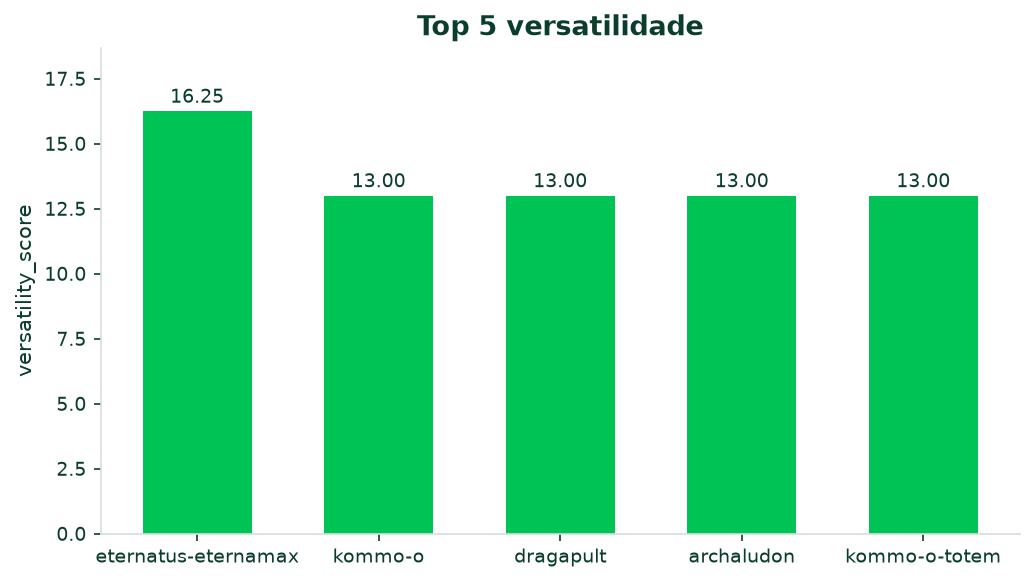

In [9]:
top5_chart_png = report.build_top5_chart(top5_list)
display(Image(data=base64.b64decode(top5_chart_png)))

### Distribuição da força (Q1)

Reforça visualmente a pegadinha da Pergunta 1: a linha tracejada é a média das
forças **por pokémon** (a mesma usada no filtro de Q1), não uma média sobre as
linhas de `pokemon_stats`.

26/09/14 01:44:12 WARN CacheManager: Asked to cache already cached data.


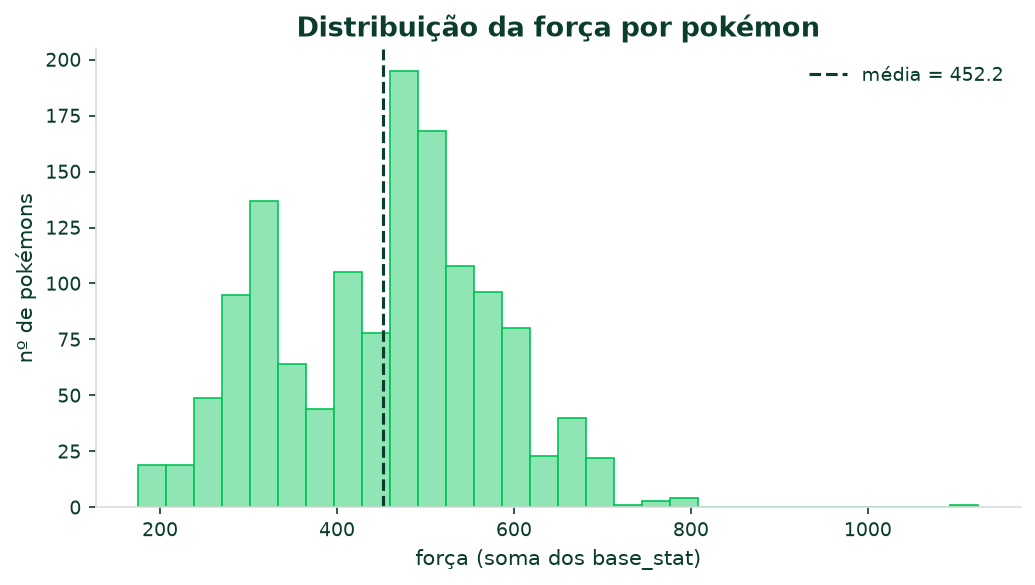

In [10]:
forca_values = [row.forca for row in analysis.forca(pokemon_stats_df).collect()]
forca_chart_png = report.build_forca_distribution_chart(forca_values)
display(Image(data=base64.b64decode(forca_chart_png)))

## Conclusão

As 3 respostas acima vêm direto das funções de `src/analysis.py`, sobre as 4
tabelas silver geradas por `src/transform.py` e validadas por `src/quality.py`.
Nenhuma lógica foi reimplementada aqui. Detalhe de implementação, tradeoffs e
estratégia de testes de cada módulo (incluindo a pegadinha da média e a lógica
do `subtract` de Q2) estão documentados em
[`docs/IMPLEMENTATION.md`](docs/IMPLEMENTATION.md).

## 6. Relatório gerencial

Os resultados desta execução são persistidos em `data/results/latest.json`
(sobrescrito a cada execução, é o "insumo" para o relatório) e o relatório
gerencial em HTML é salvo em `data/reports/`, com a logo, as cores e a fonte
do PicPay. Os dois gráficos do relatório são os mesmos gerados na Seção 5
(mesmas funções de `src/report.py`), montados a partir dos dados desta
execução, não imagens fixas. São gravadas duas cópias do HTML:
`report-apipokemon-latest.html` (sempre sobrescrita, para abrir "a mais
recente" sem procurar nome) e `report-apipokemon-{DDMMYY}-{HHMMSS}.html` (uma
por execução, preservando o histórico). A lógica de montagem do relatório e
dos gráficos vive em `src/report.py`, testada em `tests/test_report.py`; esta
célula só chama.

In [11]:
generated_at = datetime.now()

results = report.build_results(
    generated_at=generated_at,
    ingest_seconds=ingest_seconds,
    dataset_counts={
        "pokemon": n_pokemon,
        "pokemon_type": n_pokemon_type,
        "pokemon_stats": n_pokemon_stats,
        "pokemon_ability": n_pokemon_ability,
    },
    q1_resultado=resultado_q1,
    q2_abilities=q2_abilities,
    q3_top5=top5_list,
    forca_values=forca_values,
)

results_path = report.save_results_json(results)
html = report.build_html_report(results)
latest_path, timestamped_path = report.save_html_report(html, generated_at)

print(f"Resultados salvos em: {results_path}")
print(f"Relatório (mais recente): {latest_path}")
print(f"Relatório (esta execução): {timestamped_path}")

Resultados salvos em: data/results/latest.json
Relatório (mais recente): data/reports/report-apipokemon-latest.html
Relatório (esta execução): data/reports/report-apipokemon-140926-014413.html
